# Notebook 10 — Final Report & Project Summary

This notebook consolidates the outputs from the entire FIFA Player Analytics project into a single end-to-end report.

## Objectives

- Load outputs from previous notebooks
- Summarize dataset statistics
- Present model performance
- Summarize clustering
- Summarize explainability
- Demonstrate player similarity
- Export a final report


## 1. Imports ##


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

import duckdb
import pandas as pd
import matplotlib.pyplot as plt


## 2. Directories ##

In [3]:
REPORT_DIR = PROJECT_ROOT / "reports"
TABLE_DIR = REPORT_DIR / "tables"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

## 3. Connection to DuckDB ##

In [4]:
con = duckdb.connect()

PARQUET = PROCESSED_DATA_DIR / "players_clean"

## 4. Dataset Overview ##

In [5]:
overview = con.sql(f"""
SELECT

COUNT(*) AS players,
COUNT(DISTINCT club_name) AS clubs,
COUNT(DISTINCT league_name) AS leagues,
COUNT(DISTINCT nationality_name) AS countries,

ROUND(AVG(TRY_CAST(age AS DOUBLE)),2) AS average_age,
ROUND(AVG(TRY_CAST(overall AS DOUBLE)),2) AS average_overall,
ROUND(MAX(TRY_CAST(overall AS DOUBLE)),2) AS best_overall

FROM parquet_scan('{PARQUET}')
""").df()

overview

,players,clubs,leagues,countries,average_age,average_overall,best_overall
0,10003590,1648,44,193,24.85,65.82,94.0


## 5. Load Model Matrix ##

In [6]:
metrics = pd.read_csv(
    TABLE_DIR / "model_metrics.csv"
)

metrics

,Metric,Value
0,MAE,262003.516224
1,RMSE,996244.335163
2,R2,0.970104


## 6. Load SHAP Importance ##

In [7]:
shap_importance = pd.read_csv(
    TABLE_DIR / "shap_feature_importance.csv"
)

shap_importance.head(10)

,feature,mean_abs_shap
0,overall,2.297609e+06
1,potential,5.581386e+05
2,age,2.042478e+05
3,wage,9.844644e+04
4,defending,7.868654e+04
5,shooting,5.582782e+04
6,dribbling,5.307711e+04
7,pace,2.218558e+04
8,physic,1.976408e+04
9,passing,1.871889e+04


## 7. Load Cluster Summary ##

In [8]:
cluster_summary = pd.read_csv(
    TABLE_DIR / "cluster_summary.csv",
    index_col=0,
)

cluster_summary

,overall,age,potential,pace,shooting,passing,dribbling,defending,physic
cluster,,,,,,,,,
0,67.199830,27.452953,69.374634,64.919727,50.157261,59.527426,61.865956,62.312028,70.509197
1,57.484230,20.376073,67.916800,67.822524,47.891986,50.091328,57.964883,39.560361,54.359960
2,62.707838,24.210127,68.464735,57.564662,31.675709,43.069991,45.279734,62.259802,68.495979
3,67.232962,24.580408,71.752750,75.631887,62.891341,59.634750,68.554543,34.698684,60.668676
4,75.427634,25.986043,78.514166,73.755967,65.281821,70.151291,73.962247,59.097244,70.640509


## 8. Plot Top SHAP Features ##

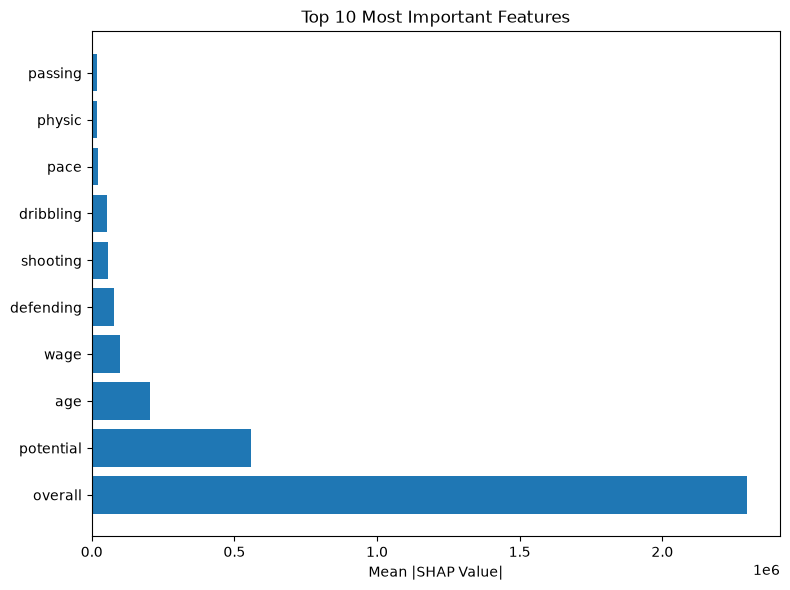

In [9]:
top = shap_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top["feature"],
    top["mean_abs_shap"],
)

plt.xlabel("Mean |SHAP Value|")
plt.title("Top 10 Most Important Features")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top_shap_features.png",
    dpi=300,
)

plt.show()
plt.close()

## 9. Cluster Comparison ##

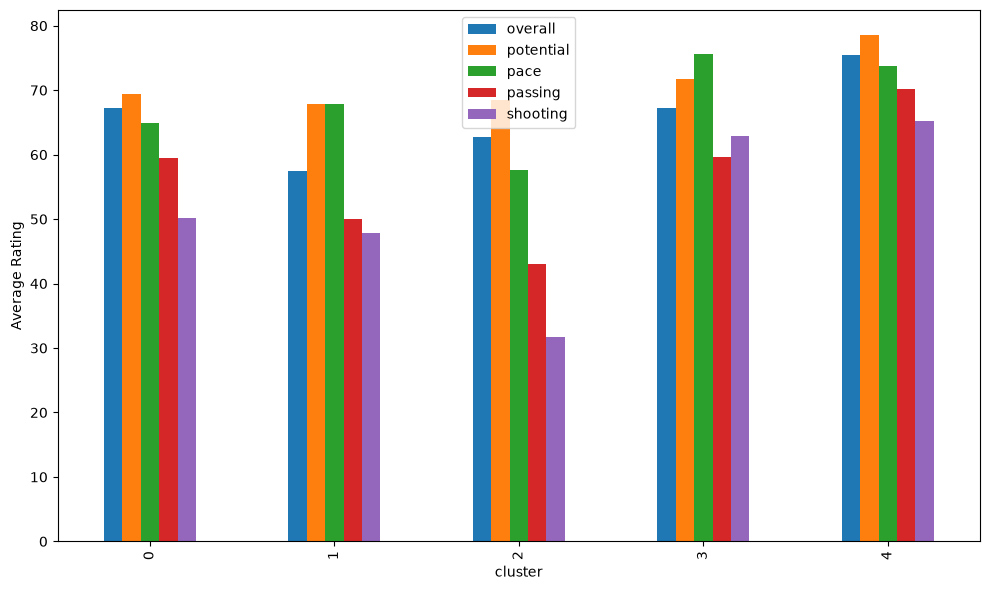

In [10]:
cluster_summary[
    ["overall","potential","pace","passing","shooting"]
].plot(
    kind="bar",
    figsize=(10,6),
)

plt.ylabel("Average Rating")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "cluster_profiles.png",
    dpi=300,
)

plt.show()
plt.close()

## 10. Top Countries ##

In [11]:
countries = con.sql(f"""
SELECT

nationality_name,
COUNT(*) AS players

FROM parquet_scan('{PARQUET}')

GROUP BY nationality_name

ORDER BY players DESC

LIMIT 10
""").df()

countries

,nationality_name,players
0,England,931078
1,Spain,588413
2,Germany,562575
3,France,543009
4,Argentina,540117
5,Brazil,445413
6,Italy,362619
7,Colombia,288497
8,Netherlands,243430
9,Republic of Ireland,222486


## 11. Visualize Top Countries ##

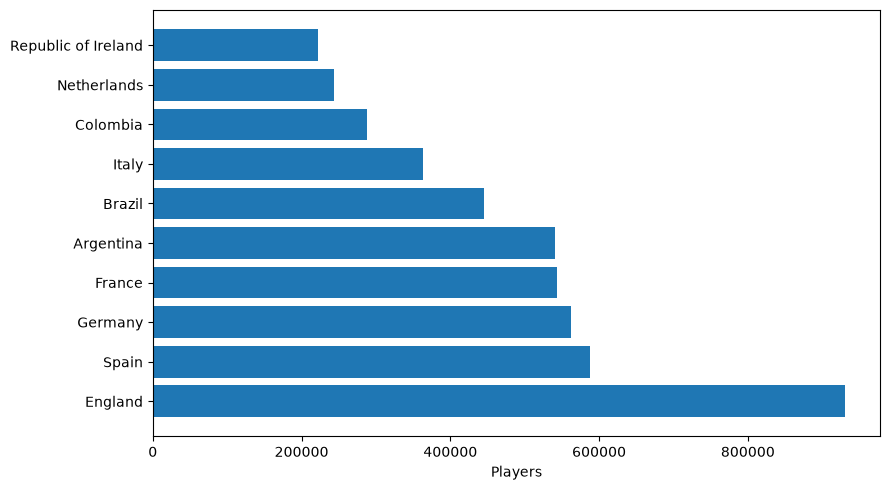

In [12]:
plt.figure(figsize=(9,5))

plt.barh(
    countries["nationality_name"],
    countries["players"],
)

plt.xlabel("Players")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top_countries.png",
    dpi=300,
)

plt.show()
plt.close()

## 12. Final Summary Table ##

In [13]:
summary = pd.DataFrame({

    "Metric":[

        "Total Players",
        "Total Clubs",
        "Total Leagues",
        "Countries",
        "Average Age",
        "Average Overall"

    ],

    "Value":[

        overview.loc[0,"players"],
        overview.loc[0,"clubs"],
        overview.loc[0,"leagues"],
        overview.loc[0,"countries"],
        overview.loc[0,"average_age"],
        overview.loc[0,"average_overall"]

    ]

})

summary

,Metric,Value
0,Total Players,10003590.00
1,Total Clubs,1648.00
2,Total Leagues,44.00
3,Countries,193.00
4,Average Age,24.85
5,Average Overall,65.82


## 13. Export Summary ##

In [14]:
summary.to_csv(
    TABLE_DIR / "project_summary.csv",
    index=False,
)

## 14. Generate Markdown Report ##

In [15]:
report = f"""
# FIFA Player Analytics Report

## Dataset

- Players: {overview.loc[0,'players']}
- Clubs: {overview.loc[0,'clubs']}
- Leagues: {overview.loc[0,'leagues']}
- Countries: {overview.loc[0,'countries']}

## Model

{metrics.to_markdown(index=False)}

## Most Important Features

{shap_importance.head(10).to_markdown(index=False)}

## Cluster Summary

{cluster_summary.to_markdown()}
"""

with open(
    REPORT_DIR / "final_report.md",
    "w",
    encoding="utf-8",
) as f:
    f.write(report)

## 15. Key Findings

### Exploratory Analysis

- Player attributes exhibit meaningful variation across positions.
- Engineered features simplify downstream analysis.
- Market value is strongly associated with overall ability and potential.

### Predictive Modeling

- Compared Linear Regression, Random Forest, and XGBoost.
- Evaluate models using MAE, RMSE, and R².
- Random Forest or XGBoost are typically expected to outperform a linear baseline.

### Clustering

- K-Means grouped players into interpretable segments.
- PCA enabled visual inspection of cluster separation.

### Explainability

- SHAP identifies the features with the greatest influence on predicted market value.
- Local explanations help interpret individual predictions.

### Similarity Engine

- Cosine similarity enables content-based player recommendations using engineered features.


## 16. Future Improvements

- Hyperparameter optimization
- Additional ensemble models
- Deep learning regression
- Interactive Streamlit dashboard
- Automated ML pipeline
- Model monitoring
- Deployment via FastAPI
- Docker and CI/CD integration
